In [29]:
import matplotlib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from scipy.spatial.distance import pdist
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as lda
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as qda
from mlxtend.plotting import plot_decision_regions

plt.style.use('ggplot')
%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (12,8)
pd.options.mode.chained_assignment = None

In [30]:
df = pd.read_csv('Sleepdataset.csv')
df

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


In [31]:
print(df.shape)
df.isnull().values.any()

(374, 13)


np.True_

In [32]:
df[df.duplicated()]

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder


In [33]:
print(df.dtypes)

Person ID                    int64
Gender                         str
Age                          int64
Occupation                     str
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                   str
Blood Pressure                 str
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder                 str
dtype: object


In [34]:
df_numeric = df.select_dtypes(include=[np.number])
numeric_cols = df_numeric.columns.values
print(numeric_cols)

<StringArray>
[              'Person ID',                     'Age',
          'Sleep Duration',        'Quality of Sleep',
 'Physical Activity Level',            'Stress Level',
              'Heart Rate',             'Daily Steps']
Length: 8, dtype: str


In [35]:
df_non_numeric = df.select_dtypes(exclude=[np.number])
non_numeric_cols = df_non_numeric.columns.values
print(non_numeric_cols)

<StringArray>
['Gender', 'Occupation', 'BMI Category', 'Blood Pressure', 'Sleep Disorder']
Length: 5, dtype: str


In [36]:
df1=df
df1 = df1.drop(['Person ID'], axis=1)
df1[['Systolic_BP', 'Diastolic_BP']] = df1['Blood Pressure'].str.split('/', expand=True).astype(int)
df1 = df1.drop(['Blood Pressure'], axis=1)

df1

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic_BP,Diastolic_BP
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,NaN,126,83
1,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,NaN,125,80
2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,NaN,125,80
3,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90
4,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,Female,59,Nurse,8.1,9,75,3,Overweight,68,7000,Sleep Apnea,140,95
370,Female,59,Nurse,8.0,9,75,3,Overweight,68,7000,Sleep Apnea,140,95
371,Female,59,Nurse,8.1,9,75,3,Overweight,68,7000,Sleep Apnea,140,95
372,Female,59,Nurse,8.1,9,75,3,Overweight,68,7000,Sleep Apnea,140,95


In [37]:
print(df1.dtypes)

Gender                         str
Age                          int64
Occupation                     str
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                   str
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder                 str
Systolic_BP                  int64
Diastolic_BP                 int64
dtype: object


In [38]:
for col in df1.columns:
    pct_missing = np.mean(df1[col].isnull())
    print('{} - {}%'.format(col, round(pct_missing*100)))

Gender - 0%
Age - 0%
Occupation - 0%
Sleep Duration - 0%
Quality of Sleep - 0%
Physical Activity Level - 0%
Stress Level - 0%
BMI Category - 0%
Heart Rate - 0%
Daily Steps - 0%
Sleep Disorder - 59%
Systolic_BP - 0%
Diastolic_BP - 0%


In [39]:
df1['Sleep Disorder'] = df1['Sleep Disorder'].fillna('No Disorder')
df1

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic_BP,Diastolic_BP
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,No Disorder,126,83
1,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,No Disorder,125,80
2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,No Disorder,125,80
3,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90
4,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,Female,59,Nurse,8.1,9,75,3,Overweight,68,7000,Sleep Apnea,140,95
370,Female,59,Nurse,8.0,9,75,3,Overweight,68,7000,Sleep Apnea,140,95
371,Female,59,Nurse,8.1,9,75,3,Overweight,68,7000,Sleep Apnea,140,95
372,Female,59,Nurse,8.1,9,75,3,Overweight,68,7000,Sleep Apnea,140,95


In [40]:
df1.isnull().values.any()

np.False_

In [41]:
stats_all = df1.describe(include=[np.number]).T
stats_all

,count,mean,std,min,25%,50%,75%,max
Age,374.0,42.184492,8.673133,27.0,35.25,43.0,50.0,59.0
Sleep Duration,374.0,7.132086,0.795657,5.8,6.40,7.2,7.8,8.5
Quality of Sleep,374.0,7.312834,1.196956,4.0,6.00,7.0,8.0,9.0
Physical Activity Level,374.0,59.171123,20.830804,30.0,45.00,60.0,75.0,90.0
Stress Level,374.0,5.385027,1.774526,3.0,4.00,5.0,7.0,8.0
Heart Rate,374.0,70.165775,4.135676,65.0,68.00,70.0,72.0,86.0
Daily Steps,374.0,6816.844920,1617.915679,3000.0,5600.00,7000.0,8000.0,10000.0
Systolic_BP,374.0,128.553476,7.748118,115.0,125.00,130.0,135.0,142.0
Diastolic_BP,374.0,84.649733,6.161611,75.0,80.00,85.0,90.0,95.0


In [42]:
print(df1.dtypes)

Gender                         str
Age                          int64
Occupation                     str
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                   str
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder                 str
Systolic_BP                  int64
Diastolic_BP                 int64
dtype: object


In [43]:
for col in df1.columns:
    pct_missing = np.mean(df1[col].isnull())
    print('{} - {}%'.format(col, round(pct_missing*100)))

Gender - 0%
Age - 0%
Occupation - 0%
Sleep Duration - 0%
Quality of Sleep - 0%
Physical Activity Level - 0%
Stress Level - 0%
BMI Category - 0%
Heart Rate - 0%
Daily Steps - 0%
Sleep Disorder - 0%
Systolic_BP - 0%
Diastolic_BP - 0%


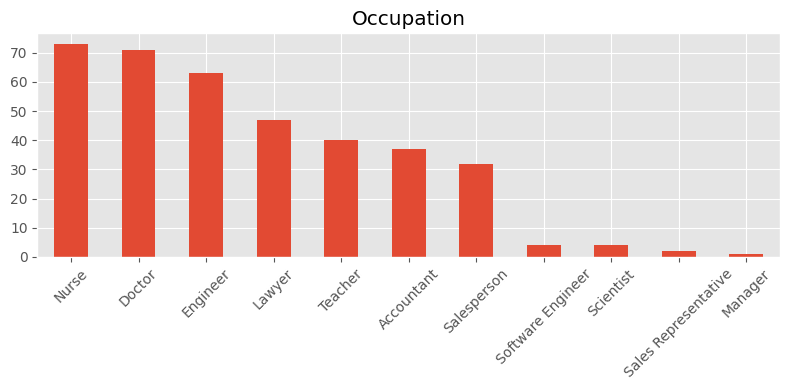

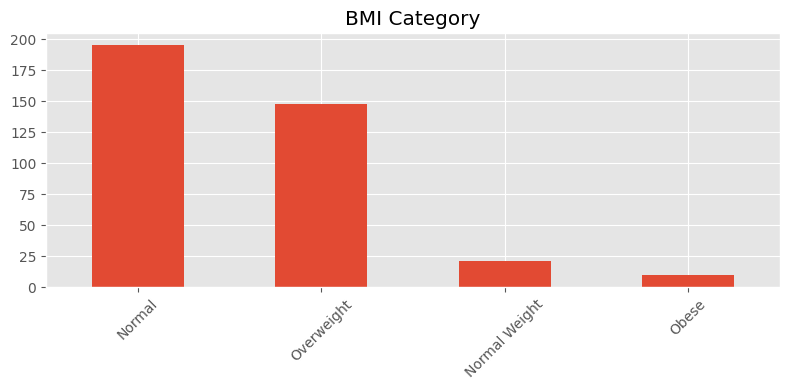

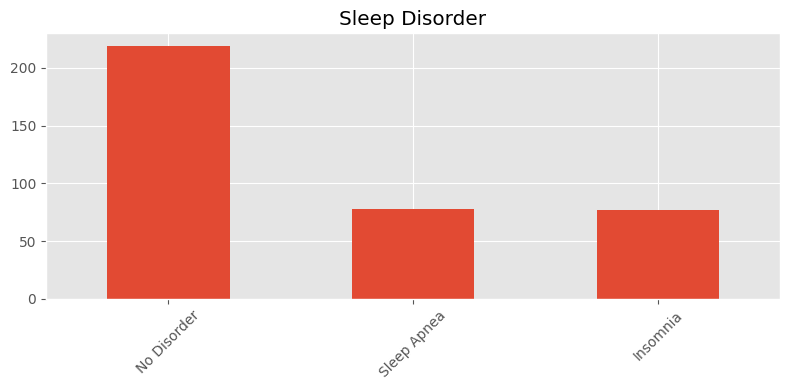

In [44]:
cat_cols = ['Occupation', 'BMI Category', 'Sleep Disorder']
for col in cat_cols:
    plt.figure(figsize=(8, 4))
    df1[col].value_counts().plot.bar()
    plt.title(col)
    plt.xlabel('')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

<Axes: xlabel='BMI Category'>

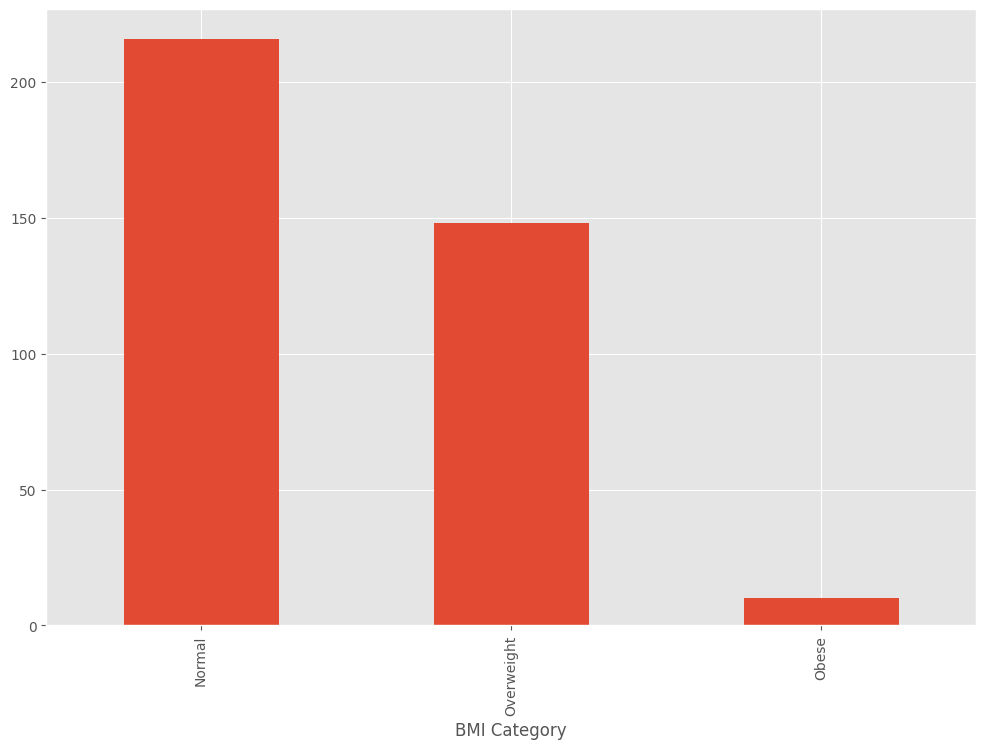

In [45]:
df1['BMI Category'] = df1['BMI Category'].replace('Normal Weight', 'Normal')
df1['BMI Category'].value_counts().plot.bar()

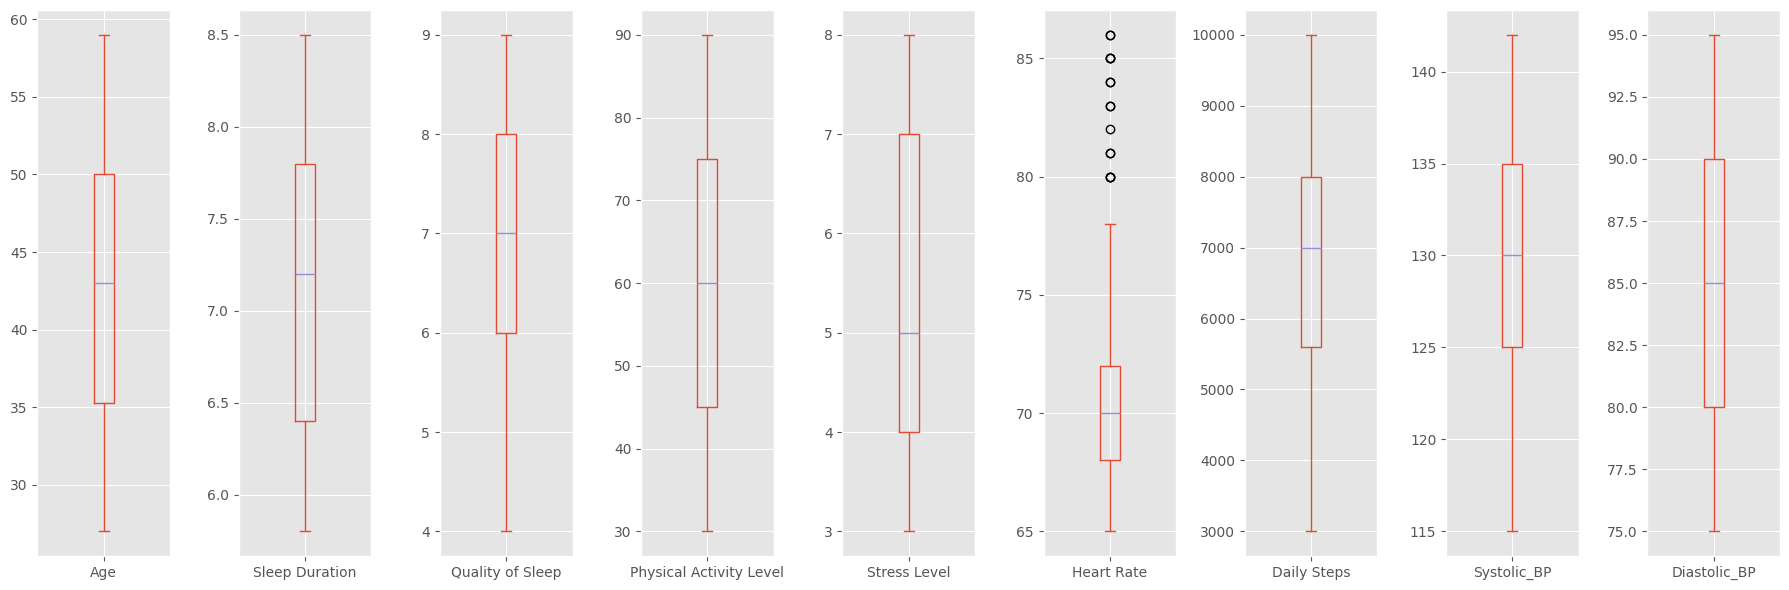

In [46]:
df_numeric = df1.select_dtypes(include=[np.number])

num_cols_count = len(df_numeric.columns)

df_numeric.plot(kind='box', subplots=True, layout=(1, num_cols_count),
                figsize=(num_cols_count*2, 6))
plt.tight_layout()
plt.show()

Нижняя граница: 65.0
Верхняя граница: 78.0


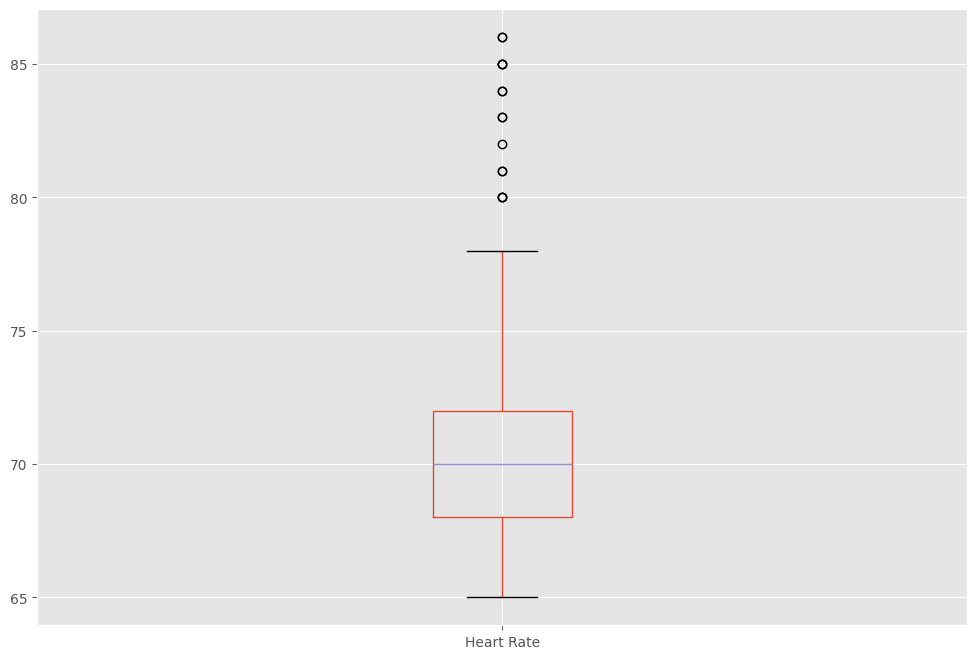

In [47]:
result = df1.boxplot(column=['Heart Rate'], return_type='dict')

lower_whisker = result['whiskers'][0].get_ydata()[1]
upper_whisker = result['whiskers'][1].get_ydata()[1]

print(f"Нижняя граница: {lower_whisker}")
print(f"Верхняя граница: {upper_whisker}")

In [48]:
numeric_cols = df1.select_dtypes(include=[np.number]).columns

In [49]:
df1 = df1[df1['Heart Rate'] <= 78]
df1 = df1[df1['Sleep Duration'] <= 10.0]

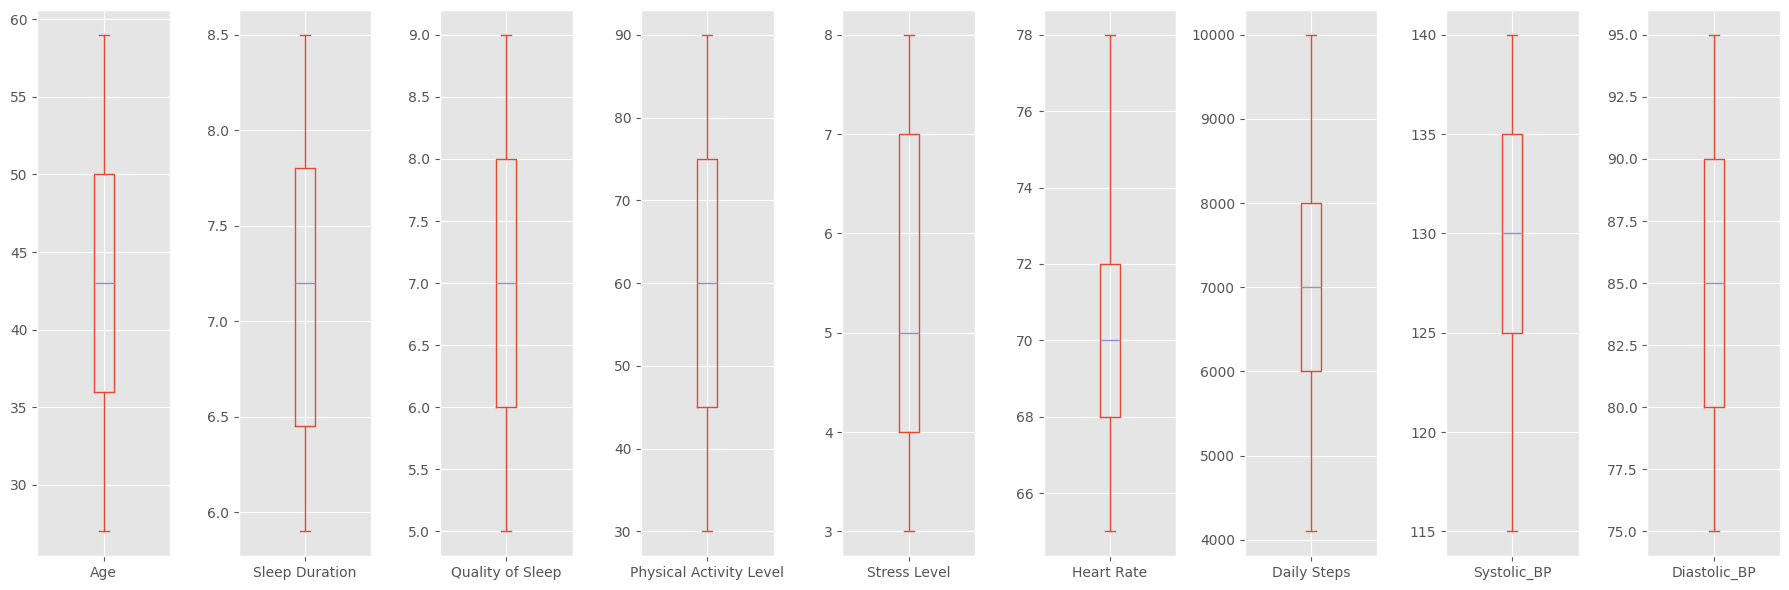

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic_BP,Diastolic_BP
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,No Disorder,126,83
1,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,No Disorder,125,80
2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,No Disorder,125,80
7,Male,29,Doctor,7.8,7,75,6,Normal,70,8000,No Disorder,120,80
8,Male,29,Doctor,7.8,7,75,6,Normal,70,8000,No Disorder,120,80
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,Female,59,Nurse,8.1,9,75,3,Overweight,68,7000,Sleep Apnea,140,95
370,Female,59,Nurse,8.0,9,75,3,Overweight,68,7000,Sleep Apnea,140,95
371,Female,59,Nurse,8.1,9,75,3,Overweight,68,7000,Sleep Apnea,140,95
372,Female,59,Nurse,8.1,9,75,3,Overweight,68,7000,Sleep Apnea,140,95


In [50]:
df_numeric = df1.select_dtypes(include=[np.number])
num_cols_count = len(df_numeric.columns)

df_numeric.plot(kind='box', subplots=True, layout=(1, num_cols_count),
                figsize=(num_cols_count*2, 6))
plt.tight_layout()
plt.show()
df1

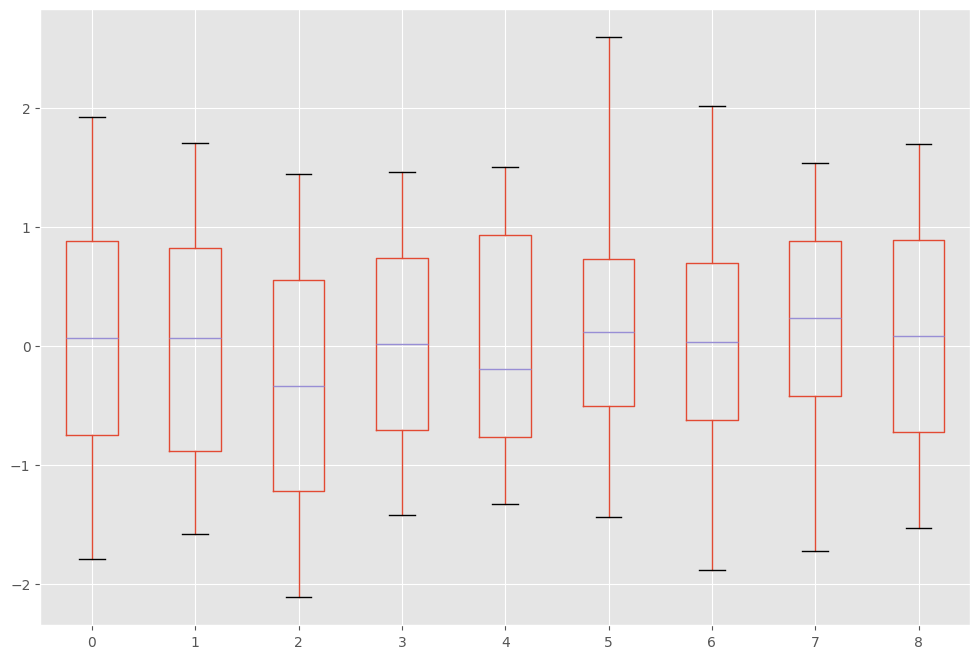

In [51]:
scaler = StandardScaler()
data_11 = pd.DataFrame (scaler.fit_transform(df_numeric))
boxplot = data_11.boxplot()

In [52]:
stats_all = data_11.describe()
stats_all

,0,1,2,3,4,5,6,7,8
count,3.590000e+02,3.590000e+02,3.590000e+02,3.590000e+02,3.590000e+02,3.590000e+02,3.590000e+02,3.590000e+02,3.590000e+02
mean,7.916911e-17,6.234567e-16,2.572996e-16,4.205859e-17,-4.948069e-17,-9.203409e-16,1.707084e-16,9.896138e-16,-3.958455e-17
std,1.001396e+00,1.001396e+00,1.001396e+00,1.001396e+00,1.001396e+00,1.001396e+00,1.001396e+00,1.001396e+00,1.001396e+00
min,-1.794529e+00,-1.582083e+00,-2.112331e+00,-1.425013e+00,-1.330948e+00,-1.434762e+00,-1.882518e+00,-1.723005e+00,-1.526902e+00
25%,-7.477475e-01,-8.857338e-01,-1.223320e+00,-7.028511e-01,-7.641506e-01,-5.050157e-01,-6.257248e-01,-4.191291e-01,-7.205504e-01
50%,6.641605e-02,6.383349e-02,-3.343080e-01,1.931131e-02,-1.973530e-01,1.148155e-01,3.574517e-02,2.328091e-01,8.580121e-02
75%,8.805796e-01,8.234873e-01,5.547036e-01,7.414737e-01,9.362424e-01,7.346467e-01,6.972152e-01,8.847473e-01,8.921529e-01
max,1.927361e+00,1.709750e+00,1.443715e+00,1.463636e+00,1.503040e+00,2.594140e+00,2.020155e+00,1.536685e+00,1.698505e+00


In [53]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(df1['Sleep Disorder'])

features = ['Heart Rate','Daily Steps', 'Quality of Sleep', 'Physical Activity Level']
X_clustering = df1[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clustering)

X_scaled = pd.DataFrame(X_scaled, columns=features)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.33, random_state=42)
print(X_train)


In [69]:
class KohonenNet():
    def __init__(self, m=3, n=3, lr=1, sigma=1, max_iter=3000, weights = []):
        self.m = m #количество классов
        self.n = n #количество уровней сети
        self.shape = (m, n)
        self.initial_lr = lr
        self.lr = lr #скорость обучения
        self.sigma = sigma #параметр изменения скорости обучения (она будет снижаться с каждой итерацией)
        self.max_iter = max_iter

        self.weights = weights

#функция нахождения выйгравшего нейрона (нейрона с минимальным расстоянием до точки)
    def _find_bmu(self, x):
        x_stack = np.stack([x]*(self.m*self.n), axis=0)#матрица размером [количество центров кластеров(нейронов), количество признаков] (для каждого веса своя строка признаков(точка))
        distance = np.linalg.norm(x_stack - self.weights, axis=1)#эвклидовы расстояния между точкой выборки и нейронами
        return np.argmin(distance)#возвращаем индекс минимального расстояния (индекс подходящего нейрона)

    def step(self, x):
        x_stack = np.stack([x]*(self.m*self.n), axis=0)#матрица размером [количество весов, количество признаков] (для каждого веса своя строка признаков(точка))

        bmu_index = self._find_bmu(x)#передаем в функцию строку признаков (точку) и получаем индекс выйгравшего нейрона (центра кластера)
        self.weights[bmu_index] += self.lr * (x - self.weights[bmu_index])

    #обучение весов
    def fit(self, X, epochs=1, shuffle=True):
        global_iter_counter = 0
        n_samples = X.shape[0]#количество элементов выборки
        total_iterations = np.minimum(epochs * n_samples, self.max_iter)#количество обучения весов в эпохе

        for epoch in range(epochs):#изначально у нас 1 эпоха
            if global_iter_counter > self.max_iter:#не даем проводить больше 3000 эпох
                break

            if shuffle:
                indices = np.random.permutation(n_samples)#создание массива с индексами в разброс
            else:
                indices = np.arange(n_samples)#создание массива с индексами по порядку

            #обучение
            for idx in indices:#проход по выборке с индексами idx
                if global_iter_counter > self.max_iter:
                    break
                input = X[idx]
                #перемещение нейрона(изменение весов победившего нейрона)
                self.step(input)

                global_iter_counter += 1
                self.lr = (1 - (global_iter_counter / total_iterations)) * self.initial_lr#изменение параметра обучения

        self._n_iter_ = global_iter_counter

        return

    def returnChangedWeights(self):
      return self.weights

    def predict(self, X):
        labels = np.array([self._find_bmu(x) for x in X])
        return labels


In [70]:
weights = np.random.uniform(
    0.4,
    0.6,
    size=(3, 4)
)

net = KohonenNet(m=3, n=1, weights=weights)
net.fit(X_train.values, shuffle=True)

result_train = net.predict(X_train.values)

result_test = net.predict(X_test.values)

In [71]:
import plotly.graph_objects as go
fig = go.Figure()

fig.add_trace(
    go.Scatter3d(
        x=X_test.iloc[:, 0],
        y=X_test.iloc[:, 1],
        z=X_test.iloc[:, 2],
        mode='markers',
        marker=dict(
            size=4,
            color=result_test
        ),
        name='Тестовые объекты'
    )
)

changed_weights = net.returnChangedWeights()

fig.add_trace(
    go.Scatter3d(
        x=changed_weights[:, 0],
        y=changed_weights[:, 1],
        z=changed_weights[:, 2],
        mode='markers',
        marker=dict(
            size=8,
            color='red',
            symbol='diamond'
        ),
        name='Нейроны'
    )
)

fig.update_layout(
    scene=dict(
        xaxis_title='Признак 1',
        yaxis_title='Признак 2',
        zaxis_title='Признак 3'
    ),
    title='Результат кластеризации тестовой выборки сетью Кохонена'
)

fig.show()

In [72]:
from mlxtend.evaluate import confusion_matrix
from sklearn.metrics import classification_report

print("Матрица ошибок для обучающей выборки:")
print(confusion_matrix(y_train, result_train))

print("\nClassification Report для обучающей выборки:")
print(classification_report(y_train, result_train))

print("Матрица ошибок для тестовой выборки:")
print(confusion_matrix(y_test, result_test))

print("\nClassification Report для тестовой выборки:")
print(classification_report(y_test, result_test))

Матрица ошибок для обучающей выборки:
[[ 5 47  1]
 [86 51  2]
 [22  2 24]]

Classification Report для обучающей выборки:
              precision    recall  f1-score   support

           0       0.04      0.09      0.06        53
           1       0.51      0.37      0.43       139
           2       0.89      0.50      0.64        48

    accuracy                           0.33       240
   macro avg       0.48      0.32      0.38       240
weighted avg       0.48      0.33      0.39       240

Матрица ошибок для тестовой выборки:
[[ 0 18  0]
 [47 31  2]
 [12  4  5]]

Classification Report для тестовой выборки:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        18
           1       0.58      0.39      0.47        80
           2       0.71      0.24      0.36        21

    accuracy                           0.30       119
   macro avg       0.43      0.21      0.27       119
weighted avg       0.52      0.30      0.38       119

kmeans, pnn, mlp на реальном а также раннюю остановку через реализацию библиотек только на реальном, сраниваем по матрцие ошибок, по времени, по количеству эпох
ранняя остановка на библиотечных сетях, dropout тоже
есть ли на валидационной выборке лос функция растет то пора остановаиться, loss функция = ошибка, это график с двумя полосами одна трейн где на трейн она падает а на валидации она начинает расти и поэтому мы говорим какая точка оптимальная, сохранить лучших весов в файл на млп, можно историю сохранять в файл и оптом загрузить!!! Лосс, обучение,
как меняется график лосс функции, и точности например(можно еще оценку взять на выбор, что то еще типа), посмотреть как на трех выборках действует,
у пнн нет эпох но есть слой большой(функция)

In [1]:
kmeans = KMeans(n_clusters=3, random_state=0).fit(X_train)
df_cluster_centers = pd.DataFrame(kmeans.cluster_centers_)
print(df_cluster_centers)

print(confusion_matrix(y_train, kmeans.labels_))
print(confusion_matrix(y_test, kmeans.predict(X_test)))
import plotly.graph_objects as go

fig = go.Figure(data=[
    go.Scatter3d(
        x=X_train[0], y=X_train[1], z=X_train[2], mode='markers', marker=dict(size=2, color=kmeans.labels_)
    ),

    go.Scatter3d(
        x=df_cluster_centers[0],
        y=df_cluster_centers[1],
        z=df_cluster_centers[2],
        mode='markers',
        marker=dict(size=4, color='red'))
]
)
fig.show()

NameError: name 'KMeans' is not defined